<a href="https://colab.research.google.com/github/madhumithasuresh-06/MachineLearningProjects/blob/main/From_Industry_to_Smart_Manufacturing_Vision_Inspection_An_Automated_Assembly_Monitoring_System_for_Defect_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%cd /content/drive/MyDrive/RasberryPi

/content/drive/MyDrive/RasberryPi


In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.0 MB/s eta 0:00:00


**Classes**

usb_ports

ethernet_port

micro_hdmi_ports

usb_c_power_port

gpio_header

audio_jack

camera_connector

display_connector

main_chip

ram_chip

In [ ]:
%%writefile data.yaml
train: /content/drive/MyDrive/RasberryPi/dataset/images/train
val: /content/drive/MyDrive/RasberryPi/dataset/images/val

nc: 10
names: [
  usb_ports,
  ethernet_port,
  micro_hdmi_ports,
  usb_c_power_port,
  gpio_header,
  audio_jack,
  camera_connector,
  display_connector,
  main_chip,
  ram_chip
]

Overwriting data.yaml


# Base Image
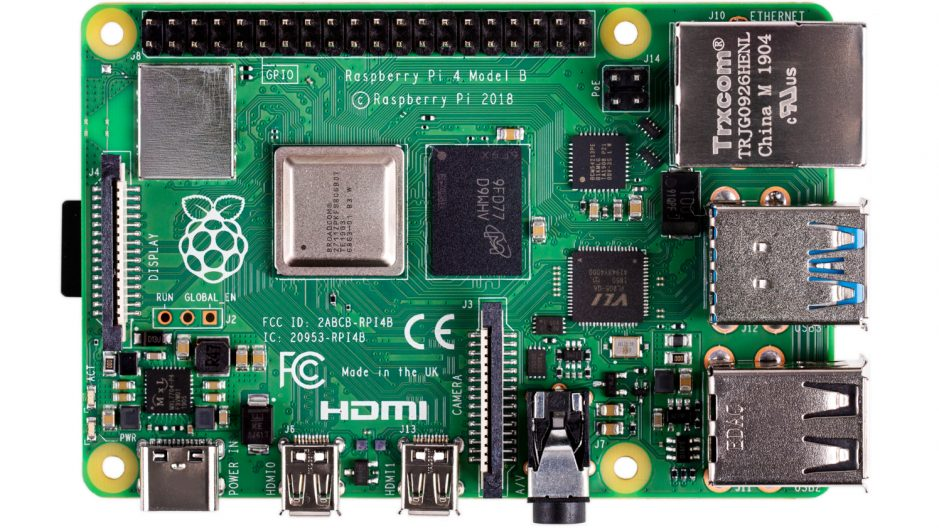

In [ ]:
# Shared configuration for the Raspberry Pi detection project

CLASSES = [
    "usb_ports",
    "ethernet_port",
    "micro_hdmi_ports",
    "usb_c_power_port",
    "gpio_header",
    "audio_jack",
    "camera_connector",
    "display_connector",
    "main_chip",
    "ram_chip"
]

# Bounding boxes in normalized coordinates [x_center, y_center, width, height]
# Adjust these based on coordinate_preview.jpg
COMPONENTS = {
    "usb_ports": [0.83, 0.55, 0.15, 0.45],
    "ethernet_port": [0.83, 0.18, 0.15, 0.25],
    "micro_hdmi_ports": [0.38, 0.88, 0.18, 0.12],
    "usb_c_power_port": [0.18, 0.88, 0.12, 0.12],
    "gpio_header": [0.45, 0.08, 0.65, 0.12],
    "audio_jack": [0.62, 0.85, 0.10, 0.15],
    "camera_connector": [0.52, 0.70, 0.05, 0.25],
    "display_connector": [0.12, 0.45, 0.05, 0.25],
    "main_chip": [0.36, 0.40, 0.15, 0.25],
    "ram_chip": [0.51, 0.40, 0.10, 0.25]
}


# Coordinate Preview
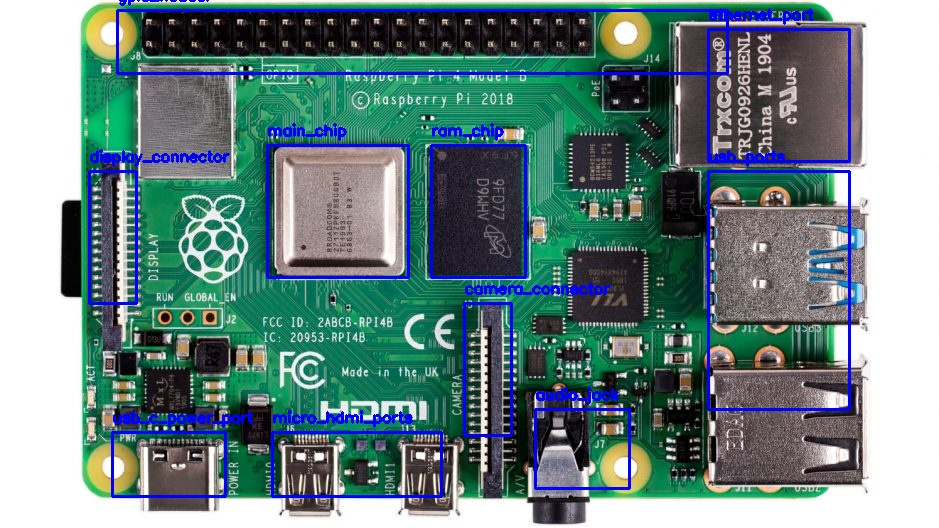

In [ ]:
from ultralytics import YOLO

def train_model():
    # Load a pretrained YOLOv8n model
    model = YOLO('yolov8n.pt')

    # Train the model
    results = model.train(
        data='data.yaml',
        epochs=20,     # Reduced from 50
        imgsz=320,     # Reduced from 640 (much faster)
        batch=16,
        name='pi_component_detector'
    )

    print("Training complete.")

if __name__ == "__main__":
    train_model()


Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pi_component_detector-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=


image 1/1 /content/drive/MyDrive/RasberryPi/dataset/images/val/pi_variant_110.jpg: 192x320 1 usb_ports, 1 micro_hdmi_ports, 1 usb_c_power_port, 1 gpio_header, 1 display_connector, 1 main_chip, 1 ram_chip, 8.2ms
Speed: 1.1ms preprocess, 8.2ms inference, 1.5ms postprocess per image at shape (1, 3, 192, 320)


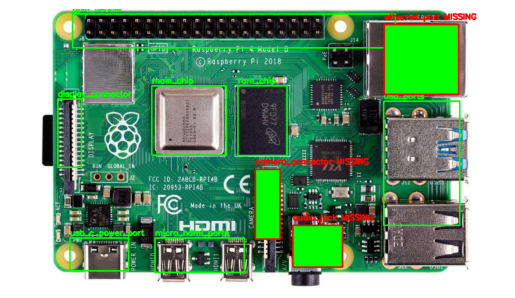

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2

# 1. Load model
model = YOLO("/content/drive/MyDrive/RasberryPi/runs/detect/pi_component_detector-5/weights/best.pt")

# 2. Image path
image_path = "/content/drive/MyDrive/RasberryPi/dataset/images/val/pi_variant_110.jpg"

# 3. Run detection
results = model(image_path)
result = results[0]

# 4. Get detected classes
detected_classes = []
for box in result.boxes:
    cls_id = int(box.cls[0])
    detected_classes.append(model.names[cls_id])

# 5. Expected components
expected = [
    "usb_ports",
    "ethernet_port",
    "micro_hdmi_ports",
    "usb_c_power_port",
    "gpio_header",
    "audio_jack",
    "camera_connector",
    "display_connector",
    "main_chip",
    "ram_chip"
]

# 6. Get image
img = result.orig_img.copy()

# 7. Draw GREEN boxes
for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_id = int(box.cls[0])
    label = model.names[cls_id]

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# ===== RED BOX FOR MISSING COMPONENTS =====
h, w, _ = img.shape

for comp in expected:
    if comp not in detected_classes:
        if comp in COMPONENTS:
            x_center, y_center, bw, bh = COMPONENTS[comp]

            # Convert normalized → pixel
            x1 = int((x_center - bw/2) * w)
            y1 = int((y_center - bh/2) * h)
            x2 = int((x_center + bw/2) * w)
            y2 = int((y_center + bh/2) * h)

            # Draw RED box
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

            # Label
            cv2.putText(img, f"{comp} MISSING",
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0, 0, 255), 2)

# 9. DISPLAY IMAGE
import matplotlib.pyplot as plt
import cv2

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()